In [51]:
# Trader Behavior Insights: Market Sentiment vs Performance

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from scipy.stats import ttest_ind


pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)


plt.style.use("ggplot")
sns.set(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [50]:

trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

print("Trader Data Shape:", trades.shape)
print("Sentiment Data Shape:", sentiment.shape)

print("\nTrader Data Preview:")
display(trades.head())

print("\nSentiment Data Preview:")
display(sentiment.head())

Trader Data Shape: (211224, 16)
Sentiment Data Shape: (2644, 4)

Trader Data Preview:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12



Sentiment Data Preview:


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [61]:
print("=== TRADER DATA INFO ===")
print(trades.info())

print("\n=== SENTIMENT DATA INFO ===")
print(sentiment.info())

print("\n=== MISSING VALUES: TRADER DATA ===")
display(trades.isnull().sum().sort_values(ascending=False))

print("\n=== MISSING VALUES: SENTIMENT DATA ===")
display(sentiment.isnull().sum().sort_values(ascending=False))

print("\n=== DUPLICATES ===")
print("Trader duplicates:", trades.duplicated().sum())
print("Sentiment duplicates:", sentiment.duplicated().sum())

=== TRADER DATA INFO ===
<class 'pandas.core.frame.DataFrame'>
Index: 79225 entries, 0 to 210649
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   account           79225 non-null  object        
 1   coin              79225 non-null  object        
 2   execution_price   79225 non-null  float64       
 3   size_tokens       79225 non-null  float64       
 4   size_usd          79225 non-null  float64       
 5   side              79225 non-null  object        
 6   timestamp_ist     79225 non-null  datetime64[ns]
 7   start_position    79225 non-null  float64       
 8   direction         79225 non-null  object        
 9   closed_pnl        79225 non-null  float64       
 10  transaction_hash  79225 non-null  object        
 11  order_id          79225 non-null  int64         
 12  crossed           79225 non-null  object        
 13  fee               79225 non-null  float64       
 14  t

,0
account,0
coin,0
execution_price,0
size_tokens,0
size_usd,0
side,0
timestamp_ist,0
start_position,0
direction,0
closed_pnl,0



=== MISSING VALUES: SENTIMENT DATA ===


,0
timestamp,0
value,0
classification,0
date,0
trade_date,0



=== DUPLICATES ===
Trader duplicates: 0
Sentiment duplicates: 0


In [56]:

trades.columns = (
    trades.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
    .str.replace("/", "_")
)

sentiment.columns = (
    sentiment.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
    .str.replace("/", "_")
)

print("Trader Columns:")
print(trades.columns.tolist())

print("\nSentiment Columns:")
print(sentiment.columns.tolist())

Trader Columns:
['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side', 'timestamp_ist', 'start_position', 'direction', 'closed_pnl', 'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id', 'timestamp']

Sentiment Columns:
['timestamp', 'value', 'classification', 'date', 'trade_date']


In [57]:
trades['timestamp_ist'] = pd.to_datetime(trades['timestamp_ist'], errors='coerce')

trades['trade_date'] = trades['timestamp_ist'].dt.date

numeric_cols = [
    'execution_price',
    'size_tokens',
    'size_usd',
    'start_position',
    'closed_pnl',
    'fee',
    'timestamp'
]

for col in numeric_cols:
    if col in trades.columns:
        trades[col] = pd.to_numeric(trades[col], errors='coerce')

categorical_cols = ['account', 'coin', 'side', 'direction', 'crossed']
for col in categorical_cols:
    if col in trades.columns:
        trades[col] = trades[col].astype(str).str.strip().str.lower()

print("Trader data cleaned successfully.")
display(trades.head())

Trader data cleaned successfully.


,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,trade_date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,buy,2024-02-12 22:50:00,0.000000,buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,true,0.345404,8.950000e+14,1.730000e+12,2024-02-12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,buy,2024-02-12 22:50:00,986.524596,buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,true,0.005600,4.430000e+14,1.730000e+12,2024-02-12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,buy,2024-02-12 22:50:00,1002.518996,buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,true,0.050431,6.600000e+14,1.730000e+12,2024-02-12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,buy,2024-02-12 22:50:00,1146.558564,buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,true,0.050043,1.080000e+15,1.730000e+12,2024-02-12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,buy,2024-02-12 22:50:00,1289.488521,buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,true,0.003055,1.050000e+15,1.730000e+12,2024-02-12


In [59]:

sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce')

sentiment['trade_date'] = sentiment['date'].dt.date

sentiment['value'] = pd.to_numeric(sentiment['value'], errors='coerce')
sentiment['timestamp'] = pd.to_numeric(sentiment['timestamp'], errors='coerce')

sentiment['classification'] = sentiment['classification'].astype(str).str.strip().str.title()

print("Sentiment data cleaned successfully.")
display(sentiment.head())

Sentiment data cleaned successfully.


,timestamp,value,classification,date,trade_date
0,1517463000,30,Fear,2018-02-01,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02,2018-02-02
2,1517635800,40,Fear,2018-02-03,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05,2018-02-05


In [60]:
trades = trades.drop_duplicates()
sentiment = sentiment.drop_duplicates()

trades = trades.dropna(subset=['trade_date', 'closed_pnl', 'size_usd'])
sentiment = sentiment.dropna(subset=['trade_date', 'classification'])

print("Final Trader Data Shape:", trades.shape)
print("Final Sentiment Data Shape:", sentiment.shape)

Final Trader Data Shape: (79225, 17)
Final Sentiment Data Shape: (2644, 5)


In [26]:

merged = trades.merge(
    sentiment[['trade_date', 'classification', 'value']],
    on='trade_date',
    how='left'
)

print("Merged Data Shape:", merged.shape)
display(merged.head())

print("\nSentiment Match Check:")
display(merged['classification'].value_counts(dropna=False))

Merged Data Shape: (79225, 19)


,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,trade_date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,buy,2024-02-12 22:50:00,0.000000,buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,true,0.345404,8.950000e+14,1.730000e+12,2024-02-12,Greed,70.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,buy,2024-02-12 22:50:00,986.524596,buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,true,0.005600,4.430000e+14,1.730000e+12,2024-02-12,Greed,70.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,buy,2024-02-12 22:50:00,1002.518996,buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,true,0.050431,6.600000e+14,1.730000e+12,2024-02-12,Greed,70.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,buy,2024-02-12 22:50:00,1146.558564,buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,true,0.050043,1.080000e+15,1.730000e+12,2024-02-12,Greed,70.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,buy,2024-02-12 22:50:00,1289.488521,buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,true,0.003055,1.050000e+15,1.730000e+12,2024-02-12,Greed,70.0



Sentiment Match Check:


,count
classification,
NaN,43361
Fear,13869
Greed,11292
Extreme Greed,5621
Neutral,2756
Extreme Fear,2326


In [27]:

merged['is_profit'] = merged['closed_pnl'] > 0
merged['is_loss'] = merged['closed_pnl'] < 0
merged['abs_pnl'] = merged['closed_pnl'].abs()

merged['trade_value'] = merged['execution_price'] * merged['size_tokens']

merged['size_bucket'] = pd.qcut(
    merged['size_usd'],
    q=4,
    labels=['Small', 'Medium', 'Large', 'Very Large'],
    duplicates='drop'
)

merged['sentiment_bucket'] = pd.cut(
    merged['value'],
    bins=[0, 25, 45, 55, 75, 100],
    labels=['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
)

print("Feature engineering complete.")
display(merged.head())

Feature engineering complete.


,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,trade_date,classification,value,is_profit,is_loss,abs_pnl,trade_value,size_bucket,sentiment_bucket
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,buy,2024-02-12 22:50:00,0.000000,buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,true,0.345404,8.950000e+14,1.730000e+12,2024-02-12,Greed,70.0,False,False,0.0,7872.163303,Very Large,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,buy,2024-02-12 22:50:00,986.524596,buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,true,0.005600,4.430000e+14,1.730000e+12,2024-02-12,Greed,70.0,False,False,0.0,127.680000,Small,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,buy,2024-02-12 22:50:00,1002.518996,buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,true,0.050431,6.600000e+14,1.730000e+12,2024-02-12,Greed,70.0,False,False,0.0,1150.630695,Large,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,buy,2024-02-12 22:50:00,1146.558564,buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,true,0.050043,1.080000e+15,1.730000e+12,2024-02-12,Greed,70.0,False,False,0.0,1142.038452,Large,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,buy,2024-02-12 22:50:00,1289.488521,buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,true,0.003055,1.050000e+15,1.730000e+12,2024-02-12,Greed,70.0,False,False,0.0,69.747462,Small,Greed


In [28]:

print("========== DATASET OVERVIEW ==========")
print("Total Trades:", len(merged))
print("Unique Traders:", merged['account'].nunique())
print("Unique Coins:", merged['coin'].nunique())
print("Date Range:", merged['trade_date'].min(), "to", merged['trade_date'].max())

print("\nTrades by Sentiment:")
display(merged['classification'].value_counts(dropna=False))

print("\nTop 10 Coins:")
display(merged['coin'].value_counts().head(10))

========== DATASET OVERVIEW ==========
Total Trades: 79225
Unique Traders: 32
Unique Coins: 183
Date Range: 2023-01-05 to 2025-12-04

Trades by Sentiment:


,count
classification,
NaN,43361
Fear,13869
Greed,11292
Extreme Greed,5621
Neutral,2756
Extreme Fear,2326



Top 10 Coins:


,count
coin,
hype,22783
@107,10271
btc,9660
eth,6834
sol,5992
fartcoin,1688
xrp,1221
melania,1136
purr/usdc,914


In [29]:

sentiment_summary = merged.groupby('classification').agg({
    'closed_pnl': ['count', 'mean', 'median', 'sum'],
    'size_usd': 'mean',
    'execution_price': 'mean',
    'is_profit': 'mean',
    'fee': 'mean'
}).reset_index()

sentiment_summary.columns = [
    'classification',
    'num_trades',
    'avg_pnl',
    'median_pnl',
    'total_pnl',
    'avg_size_usd',
    'avg_execution_price',
    'win_rate',
    'avg_fee'
]

display(sentiment_summary)

,classification,num_trades,avg_pnl,median_pnl,total_pnl,avg_size_usd,avg_execution_price,win_rate,avg_fee
0,Extreme Fear,2326,1.891632,0.00000,4.399937e+03,4118.761840,5604.219568,0.292777,0.686479
1,Extreme Greed,5621,205.816345,0.96048,1.156894e+06,3242.085086,4545.600449,0.553282,0.835794
2,Fear,13869,128.287950,0.00000,1.779226e+06,5744.782685,6846.547731,0.381787,1.131521
3,Greed,11292,53.988003,0.00000,6.096325e+05,5051.878829,11004.638053,0.435707,1.092947
4,Neutral,2756,27.088803,0.00000,7.465674e+04,4332.202906,5309.524631,0.494920,0.922389


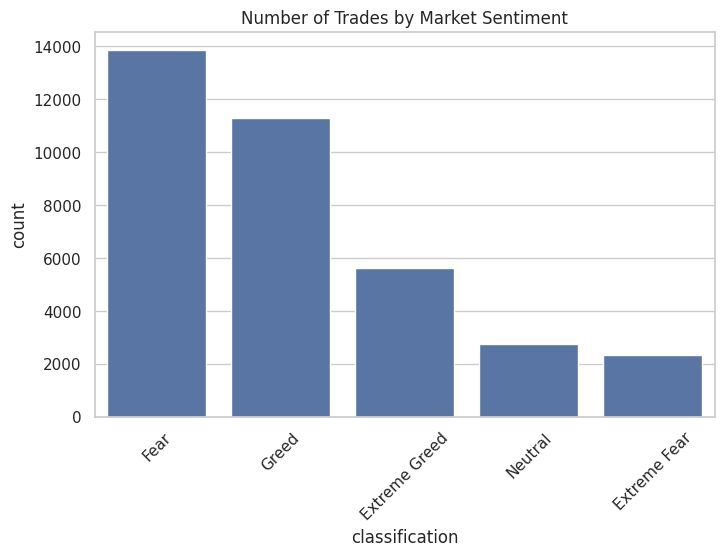

In [31]:
plt.figure(figsize=(8,5))
sns.countplot(data=merged, x='classification', order=merged['classification'].value_counts().index)
plt.title("Number of Trades by Market Sentiment")
plt.xticks(rotation=45)
plt.show()

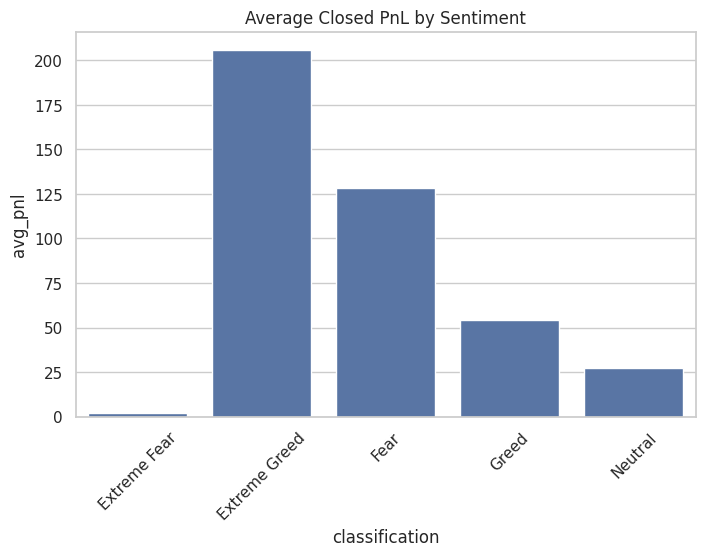

In [32]:
plt.figure(figsize=(8,5))
sns.barplot(data=sentiment_summary, x='classification', y='avg_pnl')
plt.title("Average Closed PnL by Sentiment")
plt.xticks(rotation=45)
plt.show()

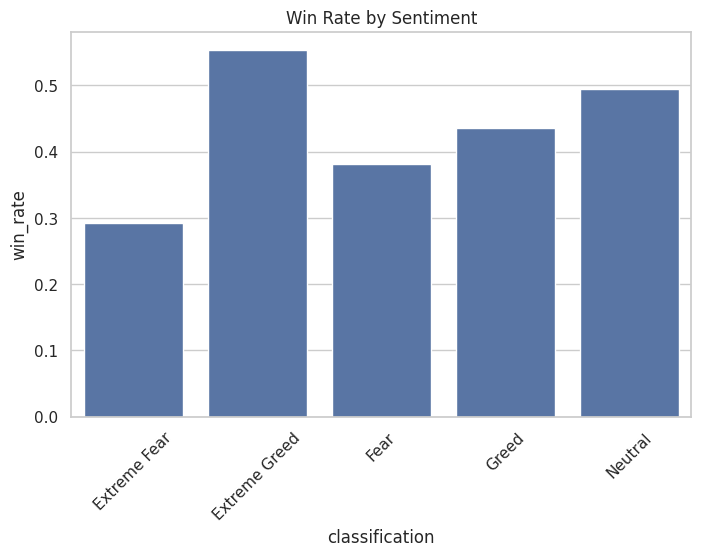

In [33]:
plt.figure(figsize=(8,5))
sns.barplot(data=sentiment_summary, x='classification', y='win_rate')
plt.title("Win Rate by Sentiment")
plt.xticks(rotation=45)
plt.show()

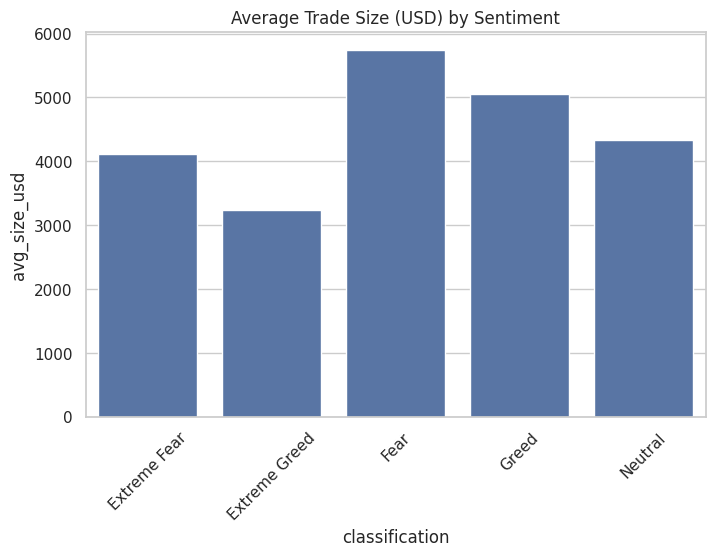

In [34]:
plt.figure(figsize=(8,5))
sns.barplot(data=sentiment_summary, x='classification', y='avg_size_usd')
plt.title("Average Trade Size (USD) by Sentiment")
plt.xticks(rotation=45)
plt.show()

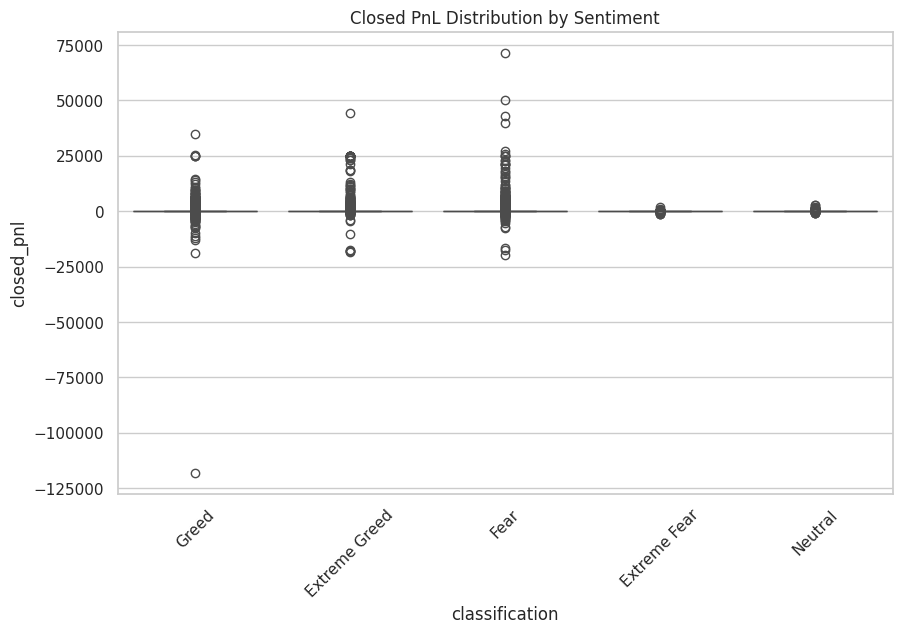

In [35]:
plt.figure(figsize=(10,6))
sns.boxplot(data=merged, x='classification', y='closed_pnl')
plt.title("Closed PnL Distribution by Sentiment")
plt.xticks(rotation=45)
plt.show()

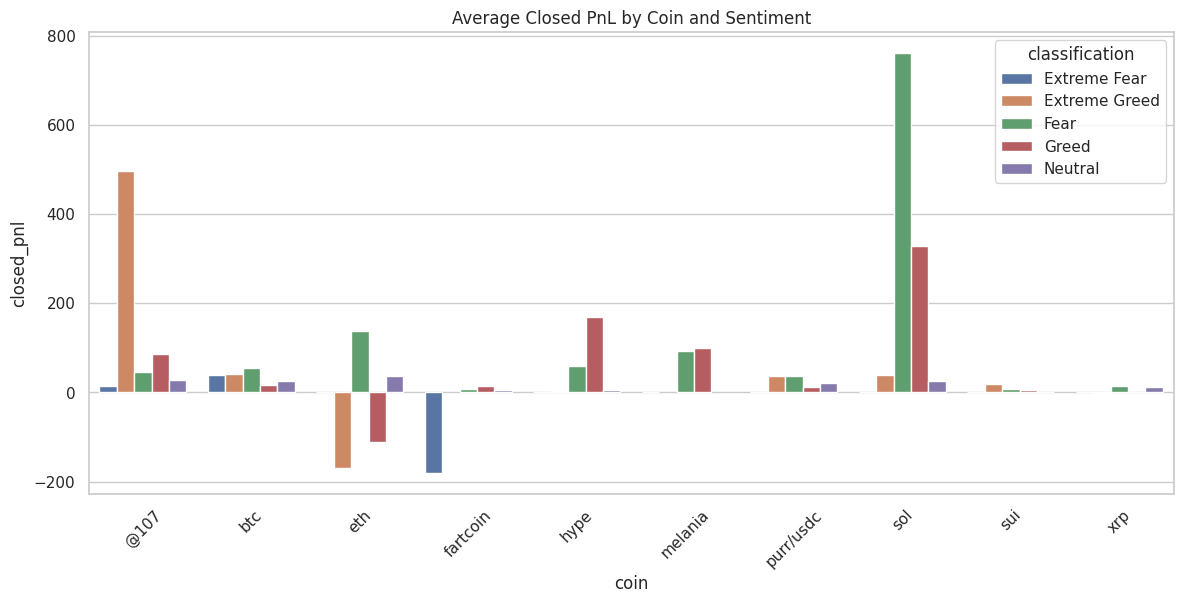

,coin,classification,closed_pnl
0,@107,Extreme Fear,14.373522
1,@107,Extreme Greed,495.650870
2,@107,Fear,45.982378
3,@107,Greed,85.776257
4,@107,Neutral,28.328571
5,btc,Extreme Fear,39.156426
6,btc,Extreme Greed,41.561424
7,btc,Fear,54.157691
8,btc,Greed,17.311808
9,btc,Neutral,26.565798


In [36]:
top_coins = merged['coin'].value_counts().head(10).index
coin_perf = merged[merged['coin'].isin(top_coins)]

coin_summary = coin_perf.groupby(['coin', 'classification'])['closed_pnl'].mean().reset_index()

plt.figure(figsize=(14,6))
sns.barplot(data=coin_summary, x='coin', y='closed_pnl', hue='classification')
plt.title("Average Closed PnL by Coin and Sentiment")
plt.xticks(rotation=45)
plt.show()

display(coin_summary)

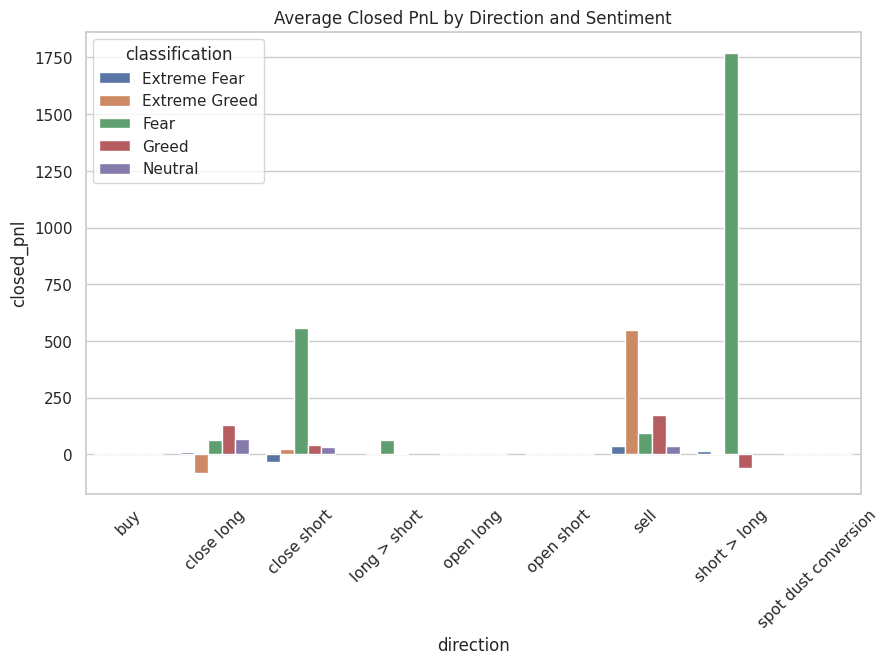

,direction,classification,closed_pnl
0,buy,Extreme Fear,0.000000
1,buy,Extreme Greed,0.000000
2,buy,Fear,0.000000
3,buy,Greed,0.000000
4,buy,Neutral,0.000000
5,close long,Extreme Fear,9.841405
6,close long,Extreme Greed,-80.470063
7,close long,Fear,62.525120
8,close long,Greed,127.229941
9,close long,Neutral,66.008772


In [38]:
direction_perf = merged.groupby(['direction', 'classification'])['closed_pnl'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=direction_perf, x='direction', y='closed_pnl', hue='classification')
plt.title("Average Closed PnL by Direction and Sentiment")
plt.xticks(rotation=45)
plt.show()

display(direction_perf)j

In [39]:
trader_perf = merged.groupby('account').agg({
    'closed_pnl': ['sum', 'mean', 'median'],
    'is_profit': 'mean',
    'size_usd': 'mean',
    'fee': 'mean',
    'account': 'count'
}).reset_index()

trader_perf.columns = [
    'account',
    'total_pnl',
    'avg_pnl',
    'median_pnl',
    'win_rate',
    'avg_size_usd',
    'avg_fee',
    'num_trades'
]

trader_perf = trader_perf.sort_values('total_pnl', ascending=False)

display(trader_perf.head(10))

,account,total_pnl,avg_pnl,median_pnl,win_rate,avg_size_usd,avg_fee,num_trades
27,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,1.674353e+06,215.934141,0.000000,0.361104,3995.025099,1.032567,7754
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.359428e+06,501.263878,0.000000,0.435472,16559.604299,1.652996,2712
29,0xbaaaf6571ab7d571043ff1e313a9609a10637864,8.177643e+05,81.191850,0.012658,0.508141,3846.605968,0.519581,10072
11,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,4.048552e+05,178.036601,0.000000,0.405893,10022.557867,1.996711,2274
31,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2.731970e+05,24.559241,0.000000,0.493168,1699.592130,0.297033,11124
16,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,2.017160e+05,427.364433,0.000000,0.239407,2108.604068,0.206615,472
17,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,1.693366e+05,50.806071,10.695055,0.797180,3510.845287,0.314163,3333
15,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,1.560309e+05,211.710810,0.000000,0.488467,8976.695970,1.403328,737
13,0x513b8629fe877bb581bf244e326a047b249c4ff1,1.004826e+05,39.327831,0.000000,0.305284,28801.290536,5.699627,2555
12,0x4f93fead39b70a1824f981a54d4e55b278e9f760,9.801994e+04,33.362812,0.000000,0.351259,17670.592600,5.682905,2938


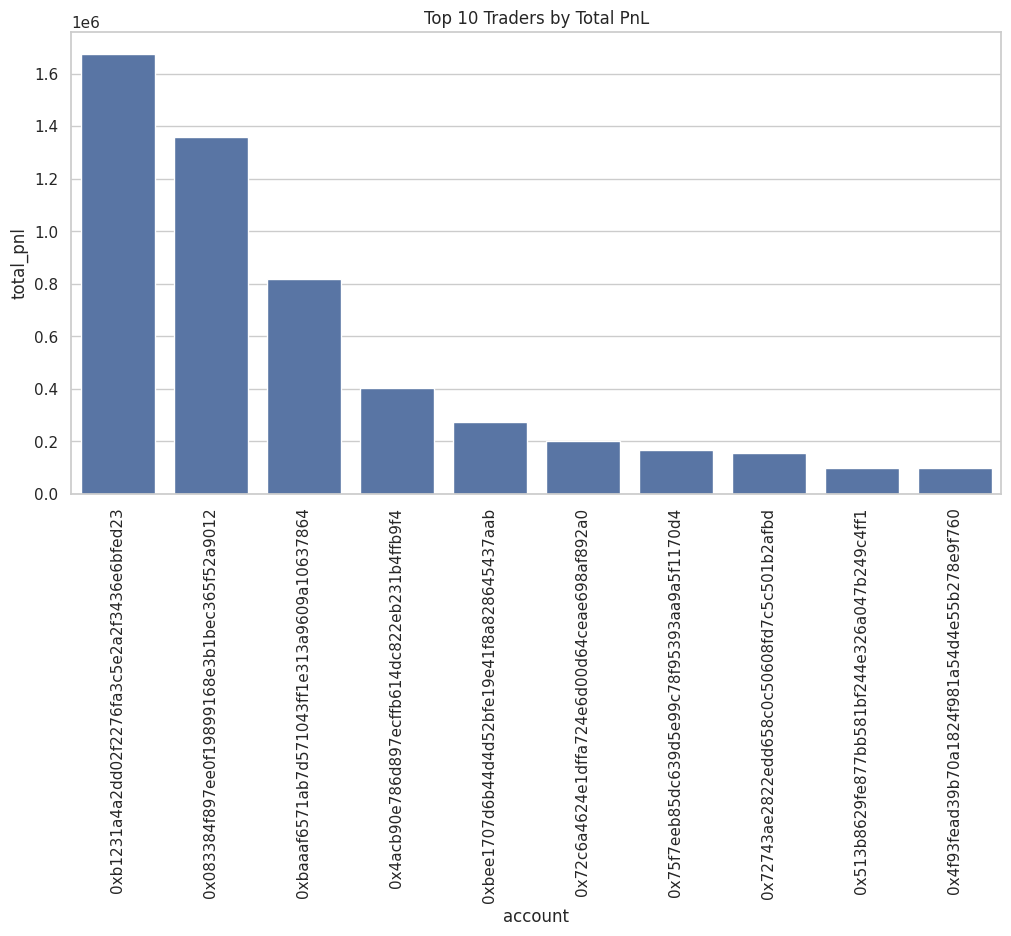

In [40]:
plt.figure(figsize=(12,6))
sns.barplot(data=trader_perf.head(10), x='account', y='total_pnl')
plt.title("Top 10 Traders by Total PnL")
plt.xticks(rotation=90)
plt.show()